# Computation of Dilution of Precision (DOP)

This notebook compares the geometric quality of two satellite configurations in a simplified two-dimensional positioning problem. It computes the position dilution of precision (PDOP) from the satellite directions as seen by a receiver.

The example isolates geometry: it assumes equal, independent range-measurement errors and does not estimate a receiver clock offset. The resulting PDOP is therefore a dimensionless multiplier relating range-error scale to position-error scale under these assumptions.

In [23]:
import numpy as np

In [24]:
rx = np.array([1, 1])

T_A = np.array([
    [5, 2],
    [-2, 4],
    [0, -4]
])

T_B = np.array([
    [5, 2],
    [-4, -7],
    [0, -4]
])

The receiver position is set to $r_x = (1, 1)$. `T_A` and `T_B` contain the coordinates of three satellites for two different layouts. The layouts share two satellite positions but differ in the second satellite, allowing us to see how changing geometry affects the precision factor.

## Compute the H matrix

For each satellite, form the receiver-to-satellite vector $\rho_i = T_i - r_x$ and normalize it to unit length. Stacking these unit vectors as rows gives the geometry matrix $H$. Each row describes the direction in which a range measurement constrains the receiver position.

In [25]:
rho_A = T_A - rx  # Implicit broadcasting of rx to the shape of T_A
rho_B = T_B - rx

In [26]:
H_A = rho_A / np.linalg.norm(rho_A, axis=1)[:, np.newaxis]  # Normalize each row of rho_A
H_B = rho_B / np.linalg.norm(rho_B, axis=1)[:, np.newaxis]  # Normalize each row of rho_B

The matrix $H^T H$ accumulates the directional information from all three ranges. Its inverse, $G = (H^T H)^{-1}$, is the position covariance factor for unit-variance range errors in this model. A well-spread set of directions constrains both coordinates; nearly aligned directions make the inverse larger and the solution more sensitive to measurement noise.

In [28]:
G_A = np.linalg.inv(H_A.T @ H_A)
G_B = np.linalg.inv(H_B.T @ H_B)

In [19]:
G_A

array([[0.67741935, 0.03225806],
       [0.03225806, 0.65927419]])

In [20]:
G_B

array([[ 1.221998 , -0.6161333],
       [-0.6161333,  0.8855454]])

In two dimensions, PDOP is the square root of the sum of the coordinate variances, or equivalently $\sqrt{\operatorname{trace}(G)}$. Comparing the two values gives a single-number summary of how strongly each satellite geometry amplifies range noise into position error.

In [29]:
PDOP_A = np.sqrt(G_A[0, 0] + G_A[1, 1])
PDOP_B = np.sqrt(G_B[0, 0] + G_B[1, 1])

In [22]:
PDOP_A, PDOP_B

(1.15615463861332, 1.4517380603803338)

## Visualize the satellite geometries

The panels use the same coordinate scale. Dashed lines show the receiver-to-satellite directions; the titles include each computed PDOP. Scenario B has two closely spaced directions, which provides weaker independent information about the receiver position.

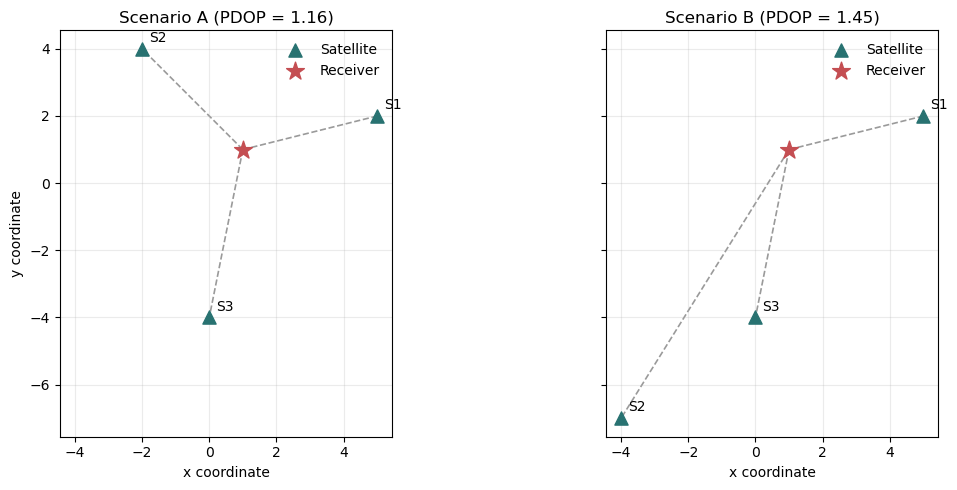

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

satellite_color = "#287271"
receiver_color = "#C44E52"
line_color = "#9A9A9A"

for axis, satellites, scenario, pdop in [
    (axes[0], T_A, "Scenario A", PDOP_A),
    (axes[1], T_B, "Scenario B", PDOP_B),
]:
    for index, satellite in enumerate(satellites, start=1):
        axis.plot(
            [rx[0], satellite[0]],
            [rx[1], satellite[1]],
            color=line_color,
            linestyle="--",
            linewidth=1.2,
            zorder=1,
        )
        axis.scatter(
            satellite[0],
            satellite[1],
            marker="^",
            s=90,
            color=satellite_color,
            label="Satellite" if index == 1 else None,
            zorder=3,
        )
        axis.annotate(
            f"S{index}",
            satellite,
            xytext=(5, 5),
            textcoords="offset points",
        )

    axis.scatter(
        rx[0],
        rx[1],
        marker="*",
        s=180,
        color=receiver_color,
        label="Receiver",
        zorder=4,
    )
    axis.set_title(f"{scenario} (PDOP = {pdop:.2f})")
    axis.set_xlabel("x coordinate")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.25)
    axis.legend(frameon=False)

axes[0].set_ylabel("y coordinate")
fig.tight_layout()
plt.show()

A lower PDOP indicates a more favorable geometry: for the same range-measurement quality, it corresponds to a smaller expected position error. The comparison is relative to these two layouts and this 2D model; it does not account for unequal measurement quality, clock bias, or other error sources.